# Reproducible EEG Preprocessing and Spectral Analysis

This notebook implements a reproducible resting-state EEG analysis using the PhysioNet EEG Motor Movement/Imagery Dataset (EEGMMIDB).

The analysis uses the expected increase in posterior alpha activity during eyes-closed compared with eyes-open resting conditions as a physiological sanity check for the preprocessing and spectral-analysis pipeline.

Participants 1–10 were used for pipeline development and quality control. After analytical decisions were fixed, the same pipeline was applied unchanged to participants 11–30 as a held-out validation subset from the same dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci
from scipy.stats import wilcoxon

## EEG Preprocessing

For each participant, Run 1 (eyes open) and Run 2 (eyes closed) are retrieved programmatically through the MNE EEGBCI interface.

Channel labels are standardised to match MNE nomenclature before applying the `standard_1005` montage. Continuous EEG is then band-pass filtered from 1–40 Hz and re-referenced to the average reference.

The same preprocessing function is applied to every participant without participant-specific modification.

In [2]:
def load_preprocess_subject(subject):
    """Load and preprocess eyes-open and eyes-closed EEG for one participant."""

    # Run 1 = eyes open; Run 2 = eyes closed
    paths = eegbci.load_data(subject, runs=[1, 2])

    eyes_open = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    eyes_closed = mne.io.read_raw_edf(paths[1], preload=True, verbose=False)

    def fix_channel_names(raw):
        """Convert EEGBCI channel labels to MNE-compatible standard names."""
        rename_map = {}

        for channel in raw.ch_names:
            new_name = channel.rstrip(".").upper()

            if new_name.endswith("Z"):
                new_name = new_name[:-1] + "z"

            fp_fix = {
                "FP1": "Fp1",
                "FPz": "Fpz",
                "FP2": "Fp2",
            }

            new_name = fp_fix.get(new_name, new_name)
            rename_map[channel] = new_name

        raw.rename_channels(rename_map)

    for raw in (eyes_open, eyes_closed):
        fix_channel_names(raw)
        raw.set_montage("standard_1005", on_missing="raise")
        raw.filter(1.0, 40.0, verbose=False)
        raw.set_eeg_reference("average", projection=False, verbose=False)

    return eyes_open, eyes_closed

## Spectral Analysis

Power spectral density is estimated using Welch's method between 1 and 40 Hz, using 320-sample windows corresponding to 2 seconds at the 160 Hz sampling rate.

Posterior alpha activity is quantified across six electrodes: O1, Oz, O2, PO3, POz, and PO4. Mean spectral power density within the 8–12 Hz alpha band is calculated separately for eyes-open and eyes-closed recordings.

Alpha reactivity is summarised using the eyes-closed/eyes-open power ratio and percentage change. The frequency with maximum power within 8–12 Hz is also recorded descriptively as the alpha-band maximum frequency.

In [3]:
def calculate_alpha_metrics(eyes_open, eyes_closed):
    """Calculate posterior alpha-band metrics for eyes-open and eyes-closed EEG."""

    posterior_channels = ["O1", "Oz", "O2", "PO3", "POz", "PO4"]

    psd_open = eyes_open.compute_psd(
        method="welch",
        fmin=1,
        fmax=40,
        n_fft=320,
        n_per_seg=320,
        verbose=False,
    )

    psd_closed = eyes_closed.compute_psd(
        method="welch",
        fmin=1,
        fmax=40,
        n_fft=320,
        n_per_seg=320,
        verbose=False,
    )

    open_data = psd_open.get_data(picks=posterior_channels)
    closed_data = psd_closed.get_data(picks=posterior_channels)

    freqs = psd_open.freqs
    alpha_mask = (freqs >= 8) & (freqs <= 12)

    alpha_open = open_data[:, alpha_mask].mean() * 1e12
    alpha_closed = closed_data[:, alpha_mask].mean() * 1e12

    alpha_ratio = alpha_closed / alpha_open
    percent_change = ((alpha_closed - alpha_open) / alpha_open) * 100

    open_spectrum = open_data.mean(axis=0)
    closed_spectrum = closed_data.mean(axis=0)

    peak_open = freqs[alpha_mask][np.argmax(open_spectrum[alpha_mask])]
    peak_closed = freqs[alpha_mask][np.argmax(closed_spectrum[alpha_mask])]

    return {
        "alpha_open": alpha_open,
        "alpha_closed": alpha_closed,
        "alpha_ratio": alpha_ratio,
        "percent_change": percent_change,
        "peak_open": peak_open,
        "peak_closed": peak_closed,
    }

In [4]:
def process_subject(subject):
    """Run the full preprocessing and alpha-analysis pipeline for one participant."""

    eyes_open, eyes_closed = load_preprocess_subject(subject)
    metrics = calculate_alpha_metrics(eyes_open, eyes_closed)

    return {
        "subject": subject,
        **metrics,
    }

In [5]:
test_result = process_subject(1)
test_result

{'subject': 1,
 'alpha_open': np.float64(21.112552922985078),
 'alpha_closed': np.float64(460.64402031437504),
 'alpha_ratio': np.float64(21.818489786371376),
 'percent_change': np.float64(2081.848978637138),
 'peak_open': np.float64(12.0),
 'peak_closed': np.float64(10.0)}

## Development and Quality-Control Subset

Participants 1–10 were used during pipeline development and quality control. This subset informed decisions about preprocessing, spectral analysis, and artefact handling before evaluation on the held-out participants.

Because analytical decisions were made after inspecting these participants, results from this subset are treated as development results rather than independent validation.

In [6]:
development_results = []

for subject in range(1, 11):
    print(f"Processing subject {subject}...")
    development_results.append(process_subject(subject))

development_df = pd.DataFrame(development_results)
development_df

Processing subject 1...
Processing subject 2...
Processing subject 3...
Processing subject 4...
Processing subject 5...
Processing subject 6...
Processing subject 7...
Processing subject 8...
Processing subject 9...
Processing subject 10...


,subject,alpha_open,alpha_closed,alpha_ratio,percent_change,peak_open,peak_closed
0,1,21.112553,460.644020,21.818490,2081.848979,12.0,10.0
1,2,15.713286,154.871382,9.856079,885.607875,11.5,11.5
2,3,14.983372,343.329670,22.914046,2191.404566,10.5,10.5
3,4,1.329821,69.120753,51.977471,5097.747111,8.0,10.5
4,5,2.612889,3.939362,1.507665,50.766487,8.5,11.0
5,6,1.876476,1.951629,1.040050,4.005029,8.0,9.0
6,7,57.240024,191.870265,3.352030,235.202976,11.0,11.5
7,8,4.031421,43.791192,10.862471,986.247053,9.0,9.5
8,9,13.627185,50.479466,3.704321,270.432098,9.0,10.5
9,10,15.875687,358.781689,22.599444,2159.944355,8.0,9.0


## Held-Out Validation Subset

Participants 11–30 were reserved as a held-out subset and processed only after the analysis pipeline had been established using participants 1–10.

The preprocessing and spectral-analysis functions were applied unchanged to these 20 participants. This provides a held-out evaluation of pipeline reproducibility within EEGMMIDB, but should not be interpreted as external validation because the development and validation participants originate from the same dataset.

In [7]:
validation_results = []

for subject in range(11, 31):
    print(f"Processing subject {subject}...")
    validation_results.append(process_subject(subject))

validation_df = pd.DataFrame(validation_results)
validation_df

Processing subject 11...
Processing subject 12...
Processing subject 13...
Processing subject 14...
Processing subject 15...
Processing subject 16...
Processing subject 17...
Processing subject 18...
Processing subject 19...
Processing subject 20...
Processing subject 21...
Processing subject 22...
Processing subject 23...
Processing subject 24...
Processing subject 25...
Processing subject 26...
Processing subject 27...
Processing subject 28...
Processing subject 29...
Processing subject 30...


,subject,alpha_open,alpha_closed,alpha_ratio,percent_change,peak_open,peak_closed
0,11,3.768083,64.299065,17.064130,1606.413016,9.5,10.5
1,12,1.777646,2.970847,1.671226,67.122566,8.0,11.5
2,13,16.944233,34.456547,2.033527,103.352651,8.0,10.5
3,14,13.501738,87.830781,6.505146,550.514614,11.5,9.5
4,15,41.713458,158.880818,3.808862,280.886228,10.5,11.0
5,16,1.024256,2.987047,2.916310,191.630962,8.0,12.0
6,17,6.390757,111.649425,17.470453,1647.045348,11.5,10.5
7,18,2.314271,12.783782,5.523891,452.389054,8.0,10.5
8,19,7.832086,12.590593,1.607566,60.756574,10.0,9.0
9,20,2.896890,35.961777,12.413928,1141.392754,8.0,11.0


## Statistical Summary

Alpha reactivity ratios are strongly right-skewed, so ratios are summarised using both the median and geometric mean. The 95% confidence interval for the geometric mean is calculated on the natural-log scale and back-transformed to the original ratio scale.

The expected directional contrast of greater posterior alpha power during eyes-closed than eyes-open recording is evaluated using a one-sided Wilcoxon signed-rank test.

Results are reported separately for the development and held-out subsets to preserve the distinction between pipeline development and subsequent held-out evaluation.

In [8]:
validation_ratios = validation_df["alpha_ratio"]

validation_median = validation_ratios.median()
validation_q1 = validation_ratios.quantile(0.25)
validation_q3 = validation_ratios.quantile(0.75)

log_ratios = np.log(validation_ratios)
validation_geo_mean = np.exp(log_ratios.mean())

n = len(log_ratios)
se = log_ratios.std(ddof=1) / np.sqrt(n)

from scipy.stats import t

t_crit = t.ppf(0.975, df=n - 1)

ci_lower = np.exp(log_ratios.mean() - t_crit * se)
ci_upper = np.exp(log_ratios.mean() + t_crit * se)

w_stat, p_value = wilcoxon(
    validation_df["alpha_closed"],
    validation_df["alpha_open"],
    alternative="greater"
)

print(f"Participants: {n}")
print(f"EC > EO: {(validation_df['alpha_closed'] > validation_df['alpha_open']).sum()}/{n}")
print(f"Median ratio: {validation_median:.2f}x")
print(f"IQR: {validation_q1:.2f}-{validation_q3:.2f}x")
print(f"Geometric mean ratio: {validation_geo_mean:.2f}x")
print(f"95% CI: {ci_lower:.2f}-{ci_upper:.2f}x")
print(f"Wilcoxon W = {w_stat:.1f}, p = {p_value:.8f}")

Participants: 20
EC > EO: 20/20
Median ratio: 5.20x
IQR: 3.59-13.34x
Geometric mean ratio: 6.06x
95% CI: 3.94-9.32x
Wilcoxon W = 210.0, p = 0.00000095


In [9]:
development_ratios = development_df["alpha_ratio"]

development_median = development_ratios.median()
development_q1 = development_ratios.quantile(0.25)
development_q3 = development_ratios.quantile(0.75)

log_ratios_dev = np.log(development_ratios)
development_geo_mean = np.exp(log_ratios_dev.mean())

n_dev = len(log_ratios_dev)
se_dev = log_ratios_dev.std(ddof=1) / np.sqrt(n_dev)

t_crit_dev = t.ppf(0.975, df=n_dev - 1)

ci_lower_dev = np.exp(
    log_ratios_dev.mean() - t_crit_dev * se_dev
)
ci_upper_dev = np.exp(
    log_ratios_dev.mean() + t_crit_dev * se_dev
)

w_dev, p_dev = wilcoxon(
    development_df["alpha_closed"],
    development_df["alpha_open"],
    alternative="greater"
)

print(f"Participants: {n_dev}")
print(
    f"EC > EO: "
    f"{(development_df['alpha_closed'] > development_df['alpha_open']).sum()}/{n_dev}"
)
print(f"Median ratio: {development_median:.2f}x")
print(f"IQR: {development_q1:.2f}-{development_q3:.2f}x")
print(f"Geometric mean ratio: {development_geo_mean:.2f}x")
print(f"95% CI: {ci_lower_dev:.2f}-{ci_upper_dev:.2f}x")
print(f"Wilcoxon W = {w_dev:.1f}, p = {p_dev:.8f}")

Participants: 10
EC > EO: 10/10
Median ratio: 10.36x
IQR: 3.44-22.40x
Geometric mean ratio: 8.11x
95% CI: 3.21-20.49x
Wilcoxon W = 55.0, p = 0.00097656


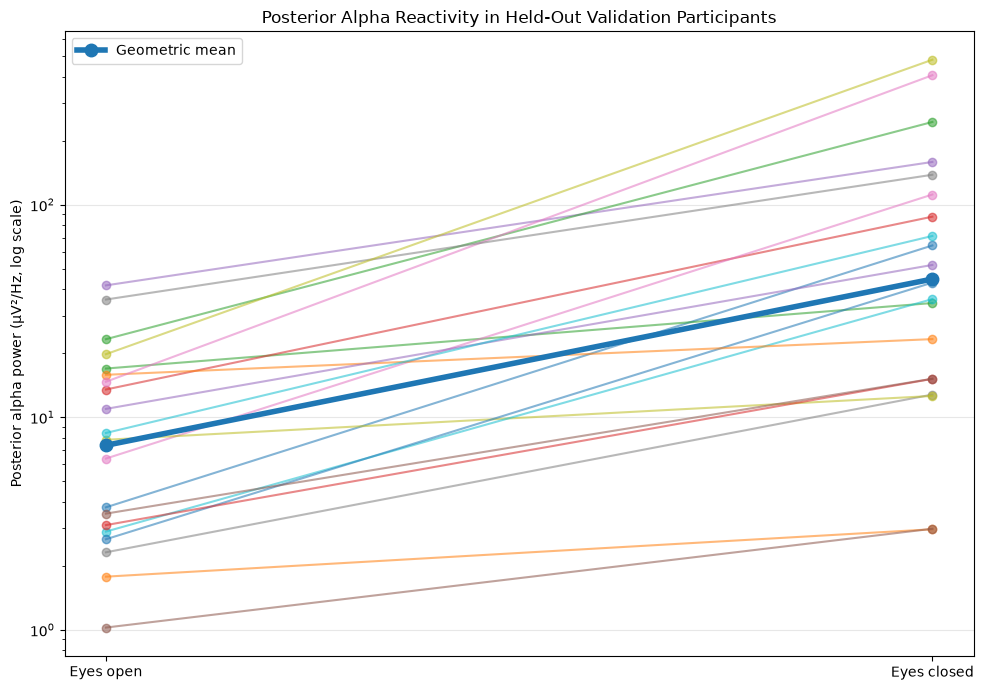

In [10]:
plt.figure(figsize=(10, 7))

for _, row in validation_df.iterrows():
    plt.plot(
        ["Eyes open", "Eyes closed"],
        [row["alpha_open"], row["alpha_closed"]],
        marker="o",
        alpha=0.55,
    )

plt.yscale("log")

geo_open = np.exp(np.log(validation_df["alpha_open"]).mean())
geo_closed = np.exp(np.log(validation_df["alpha_closed"]).mean())

plt.plot(
    ["Eyes open", "Eyes closed"],
    [geo_open, geo_closed],
    marker="o",
    linewidth=4,
    markersize=9,
    label="Geometric mean",
)

plt.ylabel("Posterior alpha power (µV²/Hz, log scale)")
plt.title("Posterior Alpha Reactivity in Held-Out Validation Participants")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/held_out_validation_alpha_reactivity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [11]:
all_results_df = pd.concat(
    [development_df, validation_df],
    ignore_index=True,
)

all_results_df.to_csv(
    "../results/alpha_results_subjects_1_30.csv",
    index=False,
)

print(f"Saved results for {len(all_results_df)} participants.")

Saved results for 30 participants.
